In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import os
import time
import torch
import pickle
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib.ticker as ticker

from e_2_CVAE import CVAE
from send_result import *
#from f_compare_bn import * 

# global var
S0 = 1.0
K = 1.0
r = 0.03
sigma = np.sqrt(0.05)
T = 1.5
BS_eta = (S0, K, r, sigma, T)
# S0, K, r, kappa, theta, xi, rho, Y0, T = Hes_eta
Hes_eta = (S0, K, r, 2, 0.05, 0.5, -0.7, 0.05, T)

B = 0.8 # down-and-out must B < S0 and B < K
model_type = 'bs' # hes, bs, bs_clip, hes_clip
# barr_type = 'barr' # van or barr
# opt_type = 'call' # call or put
if model_type == 'bs':
    chunk_dir = f"/mnt/d/bs_chunks_correction/" 
    eta_path = "/mnt/d/bs_eta_basic.h5"
elif model_type == 'bs_clip':
    chunk_dir = f"/mnt/d/bs_clip_chunks_correction/"
    eta_path = "/mnt/d/bs_eta_clip.h5"
elif model_type == 'hes':
    chunk_dir = f"/mnt/d/heston_chunks_correction/"
    eta_path = "/mnt/d/heston_eta_basic.h5"
elif model_type == 'hes_clip':
    chunk_dir = f"/mnt/d/heston_clip_chunks_correction/"
    eta_path = "/mnt/d/heston_eta_clip.h5"

if not((B < S0) & (B < K)):
    raise ValueError("down-and-out : B should be smaller than S0 and K")

# if not(opt_type == 'call' or  opt_type == 'put'):
#     raise ValueError("option_type must be 'call' or 'put'")

# if not(barr_type == 'van' or  barr_type == 'barr'):
#     raise ValueError("barr_type must be 'van' or 'barr'")

if not(model_type == 'hes' or  model_type == 'bs' or model_type == 'bs_clip' or model_type == 'hes_clip'):
    raise ValueError("model_type must be 'hes' or 'bs'")

if not(torch.cuda.is_available()):
    raise ValueError("CUDA is not available")
device = torch.device("cuda")

bs_stats = {
    "x_mean": -0.1045446063,
    "x_std": 0.6455563393,
    "m_mean": -0.4579059199,
    "m_std": 0.5553496410
}

# if model_type == 'hes':
#     if barr_type == 'barr':
#         if opt_type == 'call':
#             bench_price = 0.115733
#         else: # put
#             bench_price = 0.005170
#     else: # van
#         if opt_type == 'call':
#             bench_price = 0.124491
#         else: # put
#             bench_price = 0.080488

# elif model_type == 'bs':
#     if barr_type == 'barr':
#         if opt_type == 'call':
#             bench_price = 0.123493
#         else: # put
#             bench_price = 0.009535
#     else: # van
#         if opt_type == 'call':
#             bench_price = 0.129944
#         else: # put
#             bench_price = 0.085942

In [ ]:
# CVAE training settings
dim_z       = 2 # 2, 4, 8
hidden_dims = [1024, 1024, 512, 256] # [128, 128, 64], [512, 256, 128], [1024, 512, 256], [1024, 1024, 512, 256], [2048, 1024, 512]
batch_size  = 16384 # 1024, 2048, 128-4096, 8192, 16384, 32768, 65536
bn_chunks   = None # None or num
use_bn      = True if bn_chunks is not None else False
lr          = 2e-5 # 수렴속도 1e-4 < 1e-5
l1          = 11
lr2         = 2e-6
l2          = 12
lr3         = 1e-6
l3          = 13
beta        = 1
validation_chunk_idxs = [15,24,78]
val_every_chunks = 97
memory_on_gpu = True
warmup_chunks = None # None or num

num_chunks  = 1261
cvae_type = "add_put_loss" # "base" or "barr_weight"(exponential), "normal_weight", "add_put_loss"
weight_mode = "barrier_put" # barr_weight : "barrier_put", "barrier_near" / normal_weight, add_put_loss: "barrier_put", "all_put"
weight_alpha = 1.0
weight_h = 0.01 # 0.01, 0.03, 0.04
weight_normalize = True
resume_path = None # or None 이어서 학습하고 싶을 때

if cvae_type == "base":
#     save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
#     result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"
    save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
    result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"
#     save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{l3}-{lr3}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
#     result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{l3}-{lr3}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"

# over 4 layer 
#     save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{hidden_dims[1]}_{hidden_dims[2]}\
# _{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
#     result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{hidden_dims[1]}_{hidden_dims[2]}\
# _{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"
    
elif cvae_type == "barr_weight":
    save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{cvae_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{weight_alpha}_{weight_h}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
    result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{cvae_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{weight_alpha}_{weight_h}_{validation_chunk_idxs}_chunk{num_chunks}"
elif cvae_type == "add_put_loss":
    save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{cvae_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{weight_mode}_{weight_alpha}_{validation_chunk_idxs}_chunk{num_chunks}_fine.pt"
    result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{cvae_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{weight_mode}_{weight_alpha}_{validation_chunk_idxs}_chunk{num_chunks}_fine"


if 'base' in save_path:
    raise ValueError("base는 save_path에 포함되면 안됨.")

n_samples = 10000 # n_samples= 1k, 10k, 100k
if n_samples % 2 != 0:
    raise ValueError("n_samples should be an even number for antithetic sampling")

if model_type == 'hes':
    test_etas = [0.03, 2.0,  0.05, 0.5, -0.7, 0.05, 1.5]
    eta_keys  = ['r', 'lambda', 'v_bar', 'xi', 'rho', 'Y0', 'T']
else: # model_type = 'bs'
    test_etas = [r, sigma, T]
    eta_keys  = ['r', 'sigma', 'T']

ckpt = torch.load(save_path, map_location=device, weights_only=False)
cvae = CVAE(
    dim_x=ckpt["dim_x"],
    dim_eta=ckpt["dim_eta"],
    dim_z=ckpt["dim_z"],
    hidden_dims=ckpt["hidden_dims"],
    use_bn=ckpt.get("use_bn", False),
).to(device)

state_dict = ckpt["model_state"]
if any(k.startswith("module.") for k in state_dict):
    state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

cvae.load_state_dict(state_dict)
cvae.eval()

eta_raw = np.array(test_etas, dtype=np.float32)
eta_scaled = (eta_raw - ckpt["eta_min"]) / (ckpt["eta_max"] - ckpt["eta_min"] + 1e-8)
eta_t = torch.tensor(eta_scaled, dtype=torch.float32, device=device)

In [185]:
# CVAE training settings
dim_z       = 2 # 2, 4, 8
hidden_dims = [1024, 1024, 512, 256] # [128, 128, 64], [512, 256, 128], [1024, 512, 256], [1024, 1024, 512, 256], [2048, 1024, 512]
batch_size  = 16384 # 1024, 2048, 128-4096, 8192, 16384, 32768, 65536
bn_chunks   = None # None or num
use_bn      = True if bn_chunks is not None else False
lr          = 2e-5 # 수렴속도 1e-4 < 1e-5
l1          = 14
lr2         = 2e-6
l2          = 15
lr3         = 1e-6
l3          = 13
beta        = 1
validation_chunk_idxs = [15,24,78]
val_every_chunks = 97
memory_on_gpu = True
warmup_chunks = None # None or num

num_chunks  = 291
cvae_type = "normal_weight" # "base" or "barr_weight"(exponential), "normal_weight", "add_put_loss"
weight_mode = "barrier_put" # barr_weight : "barrier_put", "barrier_near" / normal_weight, add_put_loss: "barrier_put", "all_put"
weight_alpha = 1.0
weight_h = 0.01 # 0.01, 0.03, 0.04
weight_normalize = True
resume_path = None # or None 이어서 학습하고 싶을 때

if cvae_type == "base":
#     save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
#     result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"
#     save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
#     result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"
#     save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{l3}-{lr3}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
#     result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{l3}-{lr3}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"

# over 4 layer 
    save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{hidden_dims[1]}_{hidden_dims[2]}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
    result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}_{hidden_dims[1]}_{hidden_dims[2]}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"
    
elif cvae_type == "barr_weight":
    save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{cvae_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{weight_alpha}_{weight_h}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
    result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{cvae_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{weight_alpha}_{weight_h}_{validation_chunk_idxs}_chunk{num_chunks}"
elif cvae_type == "add_put_loss" or cvae_type == "normal_weight":
    save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{cvae_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{weight_mode}_{weight_alpha}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
    result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{cvae_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{weight_mode}_{weight_alpha}_{validation_chunk_idxs}_chunk{num_chunks}"
#     save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{cvae_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{weight_mode}_{weight_alpha}_{validation_chunk_idxs}_chunk{num_chunks}.pt"
#     result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{cvae_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{l1}-{lr}_{l2}-{lr2}_{beta}_{weight_mode}_{weight_alpha}_{validation_chunk_idxs}_chunk{num_chunks}"


if 'base' in save_path:
    raise ValueError("base는 save_path에 포함되면 안됨.")

n_samples = 10000 # n_samples= 1k, 10k, 100k
if n_samples % 2 != 0:
    raise ValueError("n_samples should be an even number for antithetic sampling")

if model_type == 'hes':
    test_etas = [0.03, 2.0,  0.05, 0.5, -0.7, 0.05, 1.5]
    eta_keys  = ['r', 'lambda', 'v_bar', 'xi', 'rho', 'Y0', 'T']
else: # model_type = 'bs'
    test_etas = [r, sigma, T]
    eta_keys  = ['r', 'sigma', 'T']

ckpt = torch.load(save_path, map_location=device, weights_only=False)
cvae = CVAE(
    dim_x=ckpt["dim_x"],
    dim_eta=ckpt["dim_eta"],
    dim_z=ckpt["dim_z"],
    hidden_dims=ckpt["hidden_dims"],
    use_bn=ckpt.get("use_bn", False),
).to(device)

state_dict = ckpt["model_state"]
if any(k.startswith("module.") for k in state_dict):
    state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

cvae.load_state_dict(state_dict)
cvae.eval()

eta_raw = np.array(test_etas, dtype=np.float32)
eta_scaled = (eta_raw - ckpt["eta_min"]) / (ckpt["eta_max"] - ckpt["eta_min"] + 1e-8)
eta_t = torch.tensor(eta_scaled, dtype=torch.float32, device=device)

# barrier put 확인 및 파라미터 확인

In [60]:
import h5py
from pathlib import Path

chunk_path = Path("/mnt/d/heston_eta_basic.h5")

with h5py.File(chunk_path, "r") as h5:
    data = h5["etas"]
    etas = data[:]

    mask = ( # bs : [r, σ, T] / hes : [r, lamb, v_bar, epsilon, rho, Y0, T] = [r, 2, 0.05, 0.5, -0.7, 0.05, T]
        # np.isclose(etas[:, 0], 0.03, atol=1e-3) &
        # np.isclose(etas[:, 1], 0.05, atol=1e-3) &
        # np.isclose(etas[:, 2], 1.50, atol=1e-2)
        np.isclose(etas[:, 0], 0.03, atol=1e-2) &
        np.isclose(etas[:, 1], 2, atol=1e-1) &
        np.isclose(etas[:, 2], 0.05, atol=1e-2) &
        np.isclose(etas[:, 3], 0.5, atol=1e-1) &
        np.isclose(etas[:, 4], -0.7, atol=1e-1) &
        np.isclose(etas[:, 5], 0.05, atol=1e-2) &
        np.isclose(etas[:, 6], 1.50, atol=1e-1)
    )

    indices = np.flatnonzero(mask)

print(etas[indices[:15],:])
print("해당 데이터 개수:", len(indices))

[[ 0.02549623  2.03400138  0.04962836  0.4256956  -0.6449425   0.05149147
   1.48112828]
 [ 0.03191545  2.06399795  0.05913385  0.48183869 -0.66053508  0.04779925
   1.51381867]
 [ 0.03025348  2.02699385  0.04739828  0.42834176 -0.78350273  0.05995157
   1.50658889]
 [ 0.02030675  1.97716558  0.05240273  0.5445552  -0.61955759  0.05901095
   1.45776603]
 [ 0.0340345   2.0050081   0.04216678  0.56854305 -0.6771267   0.04098713
   1.50811093]
 [ 0.02793278  1.94699702  0.04310769  0.43985161 -0.62630174  0.049116
   1.43117924]
 [ 0.03789554  1.9590087   0.0451546   0.41345353 -0.64852788  0.04607392
   1.4993648 ]
 [ 0.0256345   1.96013074  0.04671223  0.45376873 -0.64284316  0.05804692
   1.43402117]
 [ 0.03207305  2.02620431  0.05233434  0.55652498 -0.79695562  0.04066524
   1.58527692]]
해당 데이터 개수: 9


In [62]:
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from itertools import repeat
from multiprocessing import get_context
from pathlib import Path

from f_robust import *

chunk_dir = Path("/mnt/d/heston_chunks_correction")
chunk_paths = [
    chunk_dir / f"heston_chunk_{i:03d}.h5"
    for i in range(100)
]

target_eta_idxs = np.asarray(indices, dtype=np.int64)
row_batch_size = 100_000
max_workers = 4

matched_rows_by_file = []
with ProcessPoolExecutor( # 6m
    max_workers=max_workers,
    mp_context=get_context("spawn"),
) as executor:
    results = executor.map(
        search_chunk_for_eta_indices,
        chunk_paths,
        repeat(target_eta_idxs),
        repeat(row_batch_size),
    )

    # executor.map은 입력 파일 순서를 유지합니다.
    for chunk_name, selected in results:
        if selected is None:
            print("파일 없음:", chunk_name)
            continue

        print(f"검색 완료: {chunk_name} | 발견={len(selected):,}")
        if len(selected) > 0:
            matched_rows_by_file.append((chunk_name, selected))

if matched_rows_by_file:
    matched_rows = np.concatenate(
        [selected for _, selected in matched_rows_by_file],
        axis=0,
    )
    matched_files = np.concatenate([
        np.full(len(selected), chunk_name, dtype=object)
        for chunk_name, selected in matched_rows_by_file
    ])
    print("총 발견 개수:", len(matched_rows))
else:
    matched_rows = np.empty((0, 3), dtype=np.float64)
    matched_files = np.array([], dtype=object)
    print("해당 eta index를 찾지 못했습니다.")

검색 완료: heston_chunk_000.h5 | 발견=0
검색 완료: heston_chunk_001.h5 | 발견=0
검색 완료: heston_chunk_002.h5 | 발견=0
검색 완료: heston_chunk_003.h5 | 발견=0
검색 완료: heston_chunk_004.h5 | 발견=0
검색 완료: heston_chunk_005.h5 | 발견=0
검색 완료: heston_chunk_006.h5 | 발견=0
검색 완료: heston_chunk_007.h5 | 발견=0
검색 완료: heston_chunk_008.h5 | 발견=0
검색 완료: heston_chunk_009.h5 | 발견=0
검색 완료: heston_chunk_010.h5 | 발견=0
검색 완료: heston_chunk_011.h5 | 발견=1,024
검색 완료: heston_chunk_012.h5 | 발견=0
검색 완료: heston_chunk_013.h5 | 발견=0
검색 완료: heston_chunk_014.h5 | 발견=0
검색 완료: heston_chunk_015.h5 | 발견=1,024
검색 완료: heston_chunk_016.h5 | 발견=0
검색 완료: heston_chunk_017.h5 | 발견=0
검색 완료: heston_chunk_018.h5 | 발견=0
검색 완료: heston_chunk_019.h5 | 발견=0
검색 완료: heston_chunk_020.h5 | 발견=0
검색 완료: heston_chunk_021.h5 | 발견=0
검색 완료: heston_chunk_022.h5 | 발견=0
검색 완료: heston_chunk_023.h5 | 발견=0
검색 완료: heston_chunk_024.h5 | 발견=0
검색 완료: heston_chunk_025.h5 | 발견=0
검색 완료: heston_chunk_026.h5 | 발견=0
검색 완료: heston_chunk_027.h5 | 발견=0
검색 완료: heston_chunk_028.h5 | 발견=0
검색 완료:

In [63]:
import numpy as np

K = 1.0
B = 0.8
r = 0.03
T = 1.5

for eta_idx in target_eta_idxs:
    mask = matched_rows[:, 0].astype(np.int64) == eta_idx
    rows = matched_rows[mask]

    if len(rows) == 0:
        print(f"eta_index={eta_idx}: 데이터 없음")
        continue

    X_T = rows[:, 1]
    M_T = rows[:, 2]

    S_T = np.exp(X_T)
    alive = M_T > np.log(B)  # down-and-out barrier 생존 여부
    payoff = np.maximum(K - S_T, 0.0) * alive

    discounted_payoff = np.exp(-r * T) * payoff
    price = discounted_payoff.mean()
    std_error = discounted_payoff.std(ddof=1) / np.sqrt(len(rows))
    ci95 = 1.96 * std_error

    print(f"\neta_index={eta_idx}")
    print(f"n paths       : {len(rows):,}")
    print(f"alive ratio   : {alive.mean():.6f}")
    print(f"Barrier Put   : {price:.8f}")
    print(f"95% CI        : [{price-ci95:.8f}, {price+ci95:.8f}]")


eta_index=752503
n paths       : 1,024
alive ratio   : 0.619141
Barrier Put   : 0.00811156
95% CI        : [0.00637729, 0.00984582]

eta_index=1036011
n paths       : 1,024
alive ratio   : 0.573242
Barrier Put   : 0.00527034
95% CI        : [0.00395621, 0.00658446]

eta_index=2423114
n paths       : 1,024
alive ratio   : 0.589844
Barrier Put   : 0.00556067
95% CI        : [0.00413168, 0.00698965]

eta_index=3571287
n paths       : 1,024
alive ratio   : 0.589844
Barrier Put   : 0.00476688
95% CI        : [0.00346418, 0.00606958]

eta_index=4234508
n paths       : 1,024
alive ratio   : 0.667969
Barrier Put   : 0.00591061
95% CI        : [0.00452524, 0.00729598]

eta_index=4247254
n paths       : 1,024
alive ratio   : 0.648438
Barrier Put   : 0.00625988
95% CI        : [0.00480640, 0.00771336]

eta_index=4876066
n paths       : 1,024
alive ratio   : 0.629883
Barrier Put   : 0.00575074
95% CI        : [0.00443267, 0.00706880]

eta_index=5905995
n paths       : 1,024
alive ratio   : 0.6162

# Loss history

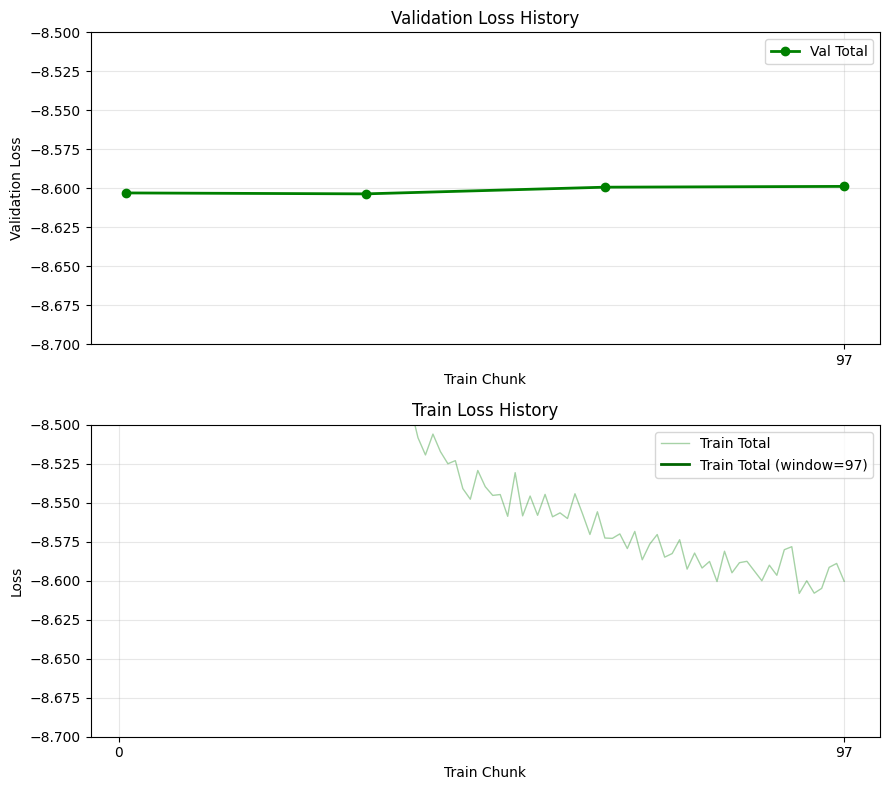

In [191]:
chunk_loss_history = ckpt.get("chunk_loss_history", None)

if chunk_loss_history is None:
    raise ValueError("checkpoint에 chunk_loss_history가 없습니다.")

train_chunks = np.arange(1, len(chunk_loss_history["total_loss"]) + 1)
val_chunks = np.asarray(chunk_loss_history.get("val_global_chunk", []), dtype=int)
has_val = len(val_chunks) > 0

n_rows = 2 if has_val else 1
fig, axes = plt.subplots(n_rows, 1, figsize=(9, 4 * n_rows), sharex=False)
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

#train loss history
# ax = axes[2]
# ax.plot(train_chunks, chunk_loss_history["total_loss"], label="Train Total", color="green", linewidth=2)
# ax.plot(train_chunks, chunk_loss_history["recon_loss"], label="Train Recon", color="blue", linestyle="--", linewidth=2)
# ax.plot(train_chunks, chunk_loss_history["KL_loss"], label="Train KL", color="orange", linewidth=2)
# ax.set_xlabel("Train Chunk")
# ax.set_ylabel("Loss")
# ax.set_title("Train Loss History")
# ax.xaxis.set_major_locator(ticker.MultipleLocator(97))
# ax.legend()
# ax.grid(True, alpha=0.3)

# validation loss history
if has_val:
    ax = axes[0]
    ax.plot(val_chunks, chunk_loss_history["val_total_loss"], marker="o", label="Val Total", color="green", linewidth=2)
    #ax.plot(val_chunks, chunk_loss_history["val_recon_loss"], marker="o", label="Val Recon", color="blue", linestyle="--", linewidth=2)
    #ax.plot(val_chunks, chunk_loss_history["val_KL_loss"], marker="o", label="Val KL", color="orange", linewidth=2)
    ax.set_xlabel("Train Chunk")
    ax.set_ylabel("Validation Loss")
    if cvae_type == "add_put_loss":
        ax.set_ylim(-8.7, -8.5)
    elif model_type =='bs' or model_type == 'bs_clip':
        ax.set_ylim(-0.765, -0.66)
        if cvae_type == "barr_weight" and weight_mode == "barrier_put":
            ax.set_ylim(-1.125, -1.0)
        if cvae_type == "normal_weight":
            ax.set_ylim(-1.1, -0.9)
    else:
        ax.set_ylim(-1.3, -1.1) # hes
    ax.set_title("Validation Loss History")
    ax.xaxis.set_major_locator(ticker.MultipleLocator(97))
    ax.legend()
    ax.grid(True, alpha=0.3)
else:
    print("validation loss history가 없습니다. validation_chunk_idxs를 넣고 학습한 checkpoint인지 확인하세요.")

window = 97
train_total_loss = np.asarray(chunk_loss_history["total_loss"], dtype=float)

ax = axes[1]
ax.plot(train_chunks, train_total_loss, label="Train Total", color="green", linewidth=1, alpha=0.35)
if len(train_total_loss) >= window:
    moving_average = np.convolve(train_total_loss, np.ones(window) / window, mode="valid")
    moving_average_chunks = train_chunks[window - 1:]
    ax.plot(
        moving_average_chunks, moving_average,
        label=f"Train Total (window={window})", color="darkgreen", linewidth=2,
    )
ax.set_xlabel("Train Chunk")
ax.set_ylabel("Loss")
if cvae_type == "add_put_loss":
    ax.set_ylim(-8.7, -8.5)
elif model_type =='bs' or model_type == 'bs_clip':
    ax.set_ylim(-0.765, -0.66)
    if cvae_type == "barr_weight" and weight_mode == "barrier_put":
        ax.set_ylim(-1.125, -1.0)
    if cvae_type == "normal_weight":
        ax.set_ylim(-1.1, -0.9)
else: # hes
    ax.set_ylim(-1.3, -1.22) 
ax.set_title("Train Loss History")
ax.xaxis.set_major_locator(ticker.MultipleLocator(97))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
# loss history
ckpt = torch.load(save_path, map_location=device, weights_only=False)
chunk_loss_history = ckpt.get("chunk_loss_history", None)
chunk_indices = ckpt["chunk_loss_history"]["chunk_idx"]

for i in range(len(chunk_loss_history["total_loss"])):
    print(f"Num : {chunk_loss_history['global_chunk'][i]}, Idx : {chunk_indices[i]}, Total Loss: {chunk_loss_history['total_loss'][i]:.4f}, Recon Loss: {chunk_loss_history['recon_loss'][i]:.4f}, KL Loss: {chunk_loss_history['KL_loss'][i]:.4f}")

Num : 0, Idx : 88, Total Loss: -0.4681, Recon Loss: -3.7710, KL Loss: 3.3029
Num : 1, Idx : 8, Total Loss: -0.6216, Recon Loss: -4.1774, KL Loss: 3.5558
Num : 2, Idx : 75, Total Loss: -0.6443, Recon Loss: -4.2178, KL Loss: 3.5735
Num : 3, Idx : 41, Total Loss: -0.6579, Recon Loss: -4.2663, KL Loss: 3.6084
Num : 4, Idx : 17, Total Loss: -0.6692, Recon Loss: -4.3095, KL Loss: 3.6402
Num : 5, Idx : 66, Total Loss: -0.7017, Recon Loss: -4.3882, KL Loss: 3.6865
Num : 6, Idx : 57, Total Loss: -0.6795, Recon Loss: -4.3846, KL Loss: 3.7051
Num : 7, Idx : 31, Total Loss: -0.6716, Recon Loss: -4.4189, KL Loss: 3.7473
Num : 8, Idx : 58, Total Loss: -0.6892, Recon Loss: -4.4331, KL Loss: 3.7439
Num : 9, Idx : 87, Total Loss: -0.6926, Recon Loss: -4.4574, KL Loss: 3.7648
Num : 10, Idx : 45, Total Loss: -0.6983, Recon Loss: -4.4815, KL Loss: 3.7833
Num : 11, Idx : 65, Total Loss: -0.6950, Recon Loss: -4.4997, KL Loss: 3.8048
Num : 12, Idx : 97, Total Loss: -0.6906, Recon Loss: -4.5165, KL Loss: 3.82

In [334]:
# validation dim-z KL mean value
chunk_loss_history = ckpt.get("chunk_loss_history", None)

if chunk_loss_history is None:
    raise ValueError("checkpoint에 chunk_loss_history가 없습니다.")

val_chunks = chunk_loss_history.get("val_global_chunk", [])
val_kl_dim_mean = chunk_loss_history.get("val_kl_dim_mean", [])

if len(val_chunks) == 0 or len(val_kl_dim_mean) == 0:
    raise ValueError("validation KL dim 기록이 없습니다. validation_chunk_idxs를 넣고 학습한 checkpoint인지 확인하세요.")

for i in range(len(val_chunks)):
    kl_by_dim = val_kl_dim_mean[i]
    kl_text = " | ".join([f"z{j}: {v:.6f}" for j, v in enumerate(kl_by_dim)])
    print(f"Num : {val_chunks[i]}, {kl_text}")


Num : 94, z0: 1.146261 | z1: 0.000052 | z2: 0.000197 | z3: 0.000079 | z4: 0.000139 | z5: 0.000155 | z6: 0.000072 | z7: 2.548793
Num : 95, z0: 1.159357 | z1: 0.000054 | z2: 0.000190 | z3: 0.000076 | z4: 0.000182 | z5: 0.000174 | z6: 0.000093 | z7: 2.566431
Num : 96, z0: 1.154737 | z1: 0.000288 | z2: 0.002688 | z3: 0.000130 | z4: 0.000481 | z5: 0.002608 | z6: 0.000147 | z7: 2.563148
Num : 97, z0: 1.147272 | z1: 0.000055 | z2: 0.000406 | z3: 0.000084 | z4: 0.000139 | z5: 0.000244 | z6: 0.000074 | z7: 2.546897
Num : 191, z0: 1.342586 | z1: 0.000028 | z2: 0.000145 | z3: 0.000065 | z4: 0.000108 | z5: 0.000097 | z6: 0.000043 | z7: 2.716001
Num : 192, z0: 1.323990 | z1: 0.000026 | z2: 0.000142 | z3: 0.000049 | z4: 0.000066 | z5: 0.000104 | z6: 0.000042 | z7: 2.683584
Num : 193, z0: 1.329768 | z1: 0.000028 | z2: 0.000185 | z3: 0.000059 | z4: 0.000089 | z5: 0.000140 | z6: 0.000042 | z7: 2.691283
Num : 194, z0: 1.334566 | z1: 0.000037 | z2: 0.000293 | z3: 0.000045 | z4: 0.000141 | z5: 0.000115 | 

# inference result

In [187]:
option_keys = ["van_call", "van_put", "barr_call", "barr_put"]
n_list = [1000, 10000, 100000]
n_repeats = 50
results_by_option = {key: {n: [] for n in n_list} for key in option_keys}

# 결과 확인용
for n in n_list:
    for _ in range(n_repeats):
        prices = cvae.total_pricing(eta_t, B, K, r, T, n)
        for key in option_keys:
            results_by_option[key][n].append(prices[key])

for key in option_keys:
    cvae_result_path = f"{result_base_path}_{key}.pkl"
    with open(cvae_result_path, "wb") as f:
        pickle.dump(results_by_option[key], f)
    print(f"saved: {cvae_result_path}")

# 시간 측정용
# for n in n_list:
#     call_time = {n: [] for n in n_list}
#     put_time = {n: [] for n in n_list}
#     for _ in range(n_repeats):
#         torch.cuda.synchronize()
#         start = time.perf_counter()
#         prices = cvae.price_vanilla(eta_t, K, r, T, "call", n)
#         torch.cuda.synchronize()
#         call_time[n].append(time.perf_counter()-start)

#     for _ in range(n_repeats):
#         torch.cuda.synchronize()
#         start = time.perf_counter()
#         prices = cvae.price_vanilla(eta_t, K, r, T, "put", n)
#         torch.cuda.synchronize()
#         put_time[n].append(time.perf_counter()-start)
    
#     print(f"van call {n} mean time : {np.mean(call_time[n]):.6f}")
#     print(f"van put {n} mean time : {np.mean(put_time[n]):.6f}")


# for n in n_list:
#     call_time = {n: [] for n in n_list}
#     put_time = {n: [] for n in n_list}
#     for _ in range(n_repeats):
#         torch.cuda.synchronize()
#         start = time.perf_counter()
#         prices = cvae.price_barrier(eta_t, B, K, r, T, "call", n)
#         torch.cuda.synchronize()
#         call_time[n].append(time.perf_counter()-start)

#     for _ in range(n_repeats):
#         torch.cuda.synchronize()
#         start = time.perf_counter()
#         prices = cvae.price_barrier(eta_t, B, K, r, T, "put", n)
#         torch.cuda.synchronize()
#         put_time[n].append(time.perf_counter()-start)
    
#     print(f"barr call {n} mean time : {np.mean(call_time[n]):.6f}")
#     print(f"barr put {n} mean time : {np.mean(put_time[n]):.6f}")

saved: result/cvae/bs/cvae_bs_normal_weight_2_1024_16384_None_2e-05_1_barrier_put_1.0_[15, 24, 78]_chunk291_van_call.pkl
saved: result/cvae/bs/cvae_bs_normal_weight_2_1024_16384_None_2e-05_1_barrier_put_1.0_[15, 24, 78]_chunk291_van_put.pkl
saved: result/cvae/bs/cvae_bs_normal_weight_2_1024_16384_None_2e-05_1_barrier_put_1.0_[15, 24, 78]_chunk291_barr_call.pkl
saved: result/cvae/bs/cvae_bs_normal_weight_2_1024_16384_None_2e-05_1_barrier_put_1.0_[15, 24, 78]_chunk291_barr_put.pkl


Vanilla Call
n=  1000 | mean=0.12628669 | std =0.00665398 |95% CI=±0.01304180 | error=-2.81%
n= 10000 | mean=0.12554863 | std =0.00208395 |95% CI=±0.00408454 | error=-3.38%
n=100000 | mean=0.12563852 | std =0.00066500 |95% CI=±0.00130341 | error=-3.31%

Vanilla Put
n=  1000 | mean=0.08504583 | std =0.00328257 |95% CI=±0.00643384 | error=-1.04%
n= 10000 | mean=0.08576629 | std =0.00111589 |95% CI=±0.00218714 | error=-0.20%
n=100000 | mean=0.08578978 | std =0.00042418 |95% CI=±0.00083140 | error=-0.18%

Barrier Call
n=  1000 | mean=0.11969587 | std =0.00643587 |95% CI=±0.01261430 | error=-3.07%
n= 10000 | mean=0.11899483 | std =0.00217157 |95% CI=±0.00425628 | error=-3.64%
n=100000 | mean=0.11909771 | std =0.00069291 |95% CI=±0.00135810 | error=-3.56%

Barrier Put
n=  1000 | mean=0.00964181 | std =0.00097365 |95% CI=±0.00190836 | error=+1.12%
n= 10000 | mean=0.00961023 | std =0.00028880 |95% CI=±0.00056605 | error=+0.79%
n=100000 | mean=0.00958650 | std =0.00008718 |95% CI=±0.00017087 | 

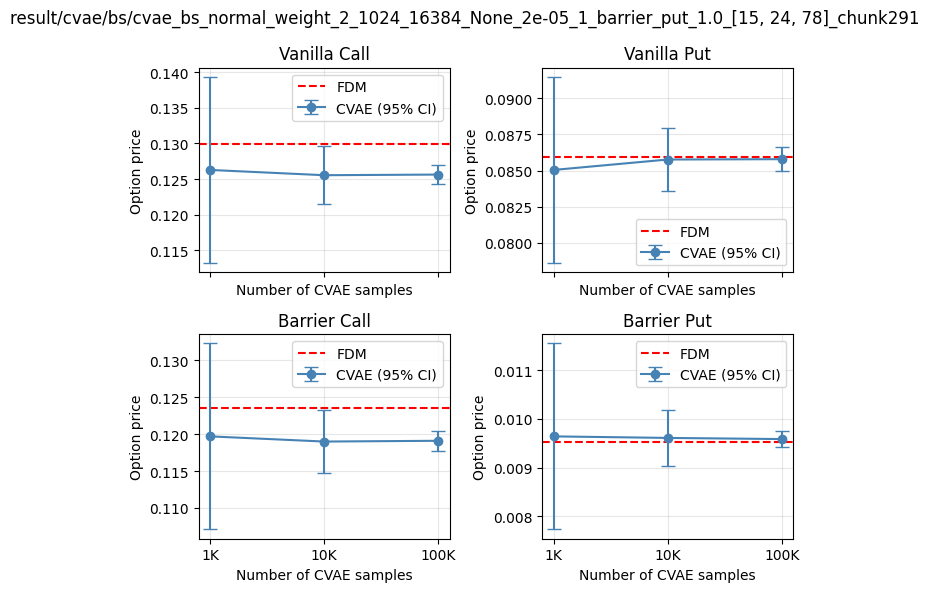

In [188]:
# CVAE inference result graphs for four option payoffs
n_list = [1000, 10000, 100000]
option_keys = ["van_call", "van_put", "barr_call", "barr_put"]
option_labels = {
    "van_call": "Vanilla Call",
    "van_put": "Vanilla Put",
    "barr_call": "Barrier Call",
    "barr_put": "Barrier Put",
}
bench_prices = {
    "hes": {
        "van_call": 0.124491,
        "van_put": 0.080488,
        "barr_call": 0.115733,
        "barr_put": 0.005170,
    },
    "bs": {
        "van_call": 0.129944,
        "van_put": 0.085942,
        "barr_call": 0.123493,
        "barr_put": 0.009535,
    },
    "hes_clip": {
        "van_call": 0.124491,
        "van_put": 0.080488,
        "barr_call": 0.115733,
        "barr_put": 0.005170,
    },
    "bs_clip": {
        "van_call": 0.129944,
        "van_put": 0.085942,
        "barr_call": 0.123493,
        "barr_put": 0.009535,
    },
}
# result_base_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
# _{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}"

fig, axes = plt.subplots(2, 2, figsize=(7, 6), sharex=True)
axes = axes.ravel()

for ax, key in zip(axes, option_keys):
    with open(f"{result_base_path}_{key}.pkl", "rb") as f:
        results = pickle.load(f)

    means = np.array([np.mean(results[n]) for n in n_list])
    stds = np.array([np.std(results[n]) for n in n_list])
    ci = 1.96 * stds
    bench = bench_prices[model_type][key]

    print(option_labels[key])
    for n, mean, std, err in zip(n_list, means, stds, ci):
        rel_err = (mean - bench) / (bench) * 100
        print(f"n={n:6d} | mean={mean:.8f} | std ={std:.8f} |95% CI=±{err:.8f} | error={rel_err:+.2f}%")
    print()

    ax.axhline(bench, color="red", linestyle='--', linewidth=1.5, label="FDM")
    ax.errorbar(
        range(len(n_list)), means,
        yerr=ci, fmt="o-", color="steelblue", capsize=5, label="CVAE (95% CI)",
    )
    ax.set_xticks(range(len(n_list)))
    ax.set_xticklabels(["1K", "10K", "100K"])
    ax.set_title(option_labels[key])
    ax.set_xlabel("Number of CVAE samples")
    ax.set_ylabel("Option price")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle(result_base_path)
plt.tight_layout()
plt.show()

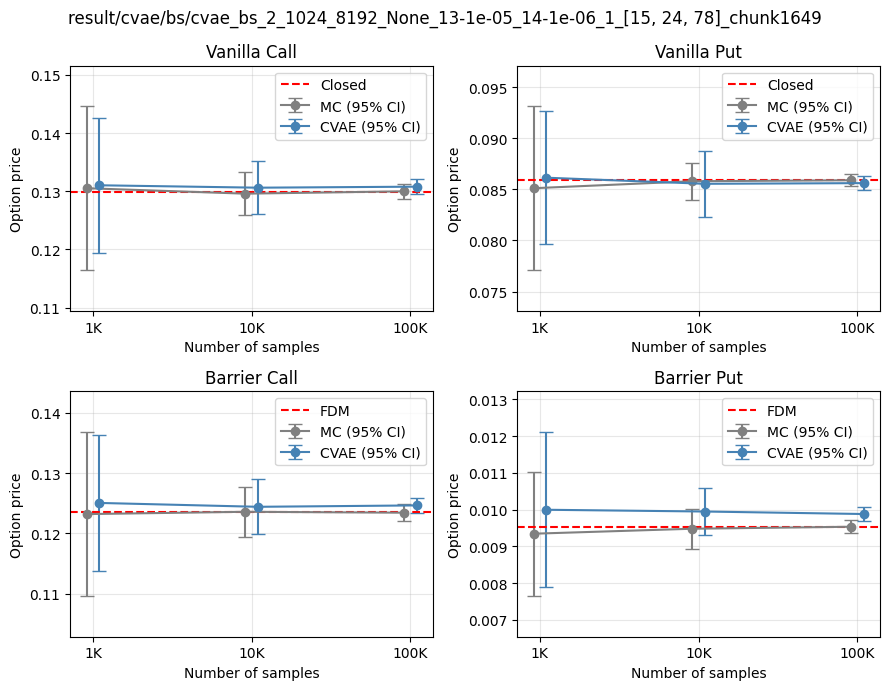

In [39]:
# 공용 그래프
n_list    = [1000, 10000, 100000]
option_keys = ["van_call", "van_put", "barr_call", "barr_put"]
option_labels = {
    "van_call": "Vanilla Call",
    "van_put": "Vanilla Put",
    "barr_call": "Barrier Call",
    "barr_put": "Barrier Put",
}
bench_prices = {
    "hes": {
        "van_call": 0.124491,
        "van_put": 0.080488,
        "barr_call": 0.115733,
        "barr_put": 0.005170,
    },
    "bs": {
        "van_call": 0.129944,
        "van_put": 0.085942,
        "barr_call": 0.123493,
        "barr_put": 0.009535,
    },
    "bs_clip": {
        "van_call": 0.129944,
        "van_put": 0.085942,
        "barr_call": 0.123493,
        "barr_put": 0.009535,
    },
}

fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True)
axes = axes.ravel()

y_axis_pad_ratio = 0.25
x_axis_offset = 0.04
x_positions = np.arange(len(n_list))

for ax, key in zip(axes, option_keys):
    with open(f"{result_base_path}_{key}.pkl", "rb") as f:
        cvae_results = pickle.load(f)
    with open(f'result/mc/mc_{model_type}_{key}_results.pkl', 'rb') as f:
        mc_results = pickle.load(f)

    cvae_means = np.array([np.mean(cvae_results[n]) for n in n_list])
    cvae_stds = np.array([np.std(cvae_results[n]) for n in n_list])
    mc_means = np.array([np.mean(mc_results[n]) for n in n_list])
    mc_stds = np.array([np.std(mc_results[n]) for n in n_list])
    cvae_ci = 1.96 * cvae_stds
    mc_ci = 1.96 * mc_stds

    bench = bench_prices[model_type][key]

    y_values = np.concatenate([
        mc_means - mc_ci,
        mc_means + mc_ci,
        cvae_means - cvae_ci,
        cvae_means + cvae_ci,
    ])
    y_min = float(np.nanmin(y_values))
    y_max = float(np.nanmax(y_values))
    y_pad = (y_max - y_min) * y_axis_pad_ratio

    ax.errorbar(
        x_positions - x_axis_offset, mc_means, yerr=mc_ci,
        fmt='o-', color='grey', capsize=5, label=f'MC (95% CI)'
    )
    ax.errorbar(
        x_positions + x_axis_offset, cvae_means, yerr=cvae_ci, 
        fmt="o-", color="steelblue", capsize=5, label="CVAE (95% CI)",
    )

    bench_label = "Closed" if key.startswith("van") else "FDM"
    ax.axhline(bench, color="r", linestyle='--', linewidth=1.5, label=bench_label)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(["1K", "10K", "100K"])
    ax.tick_params(axis="x", labelbottom=True)
    ax.set_title(option_labels[key])
    ax.set_xlabel("Number of samples")
    ax.set_ylabel("Option price")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle(result_base_path)
plt.tight_layout()
plt.show()


# MC, CVAE output distribution

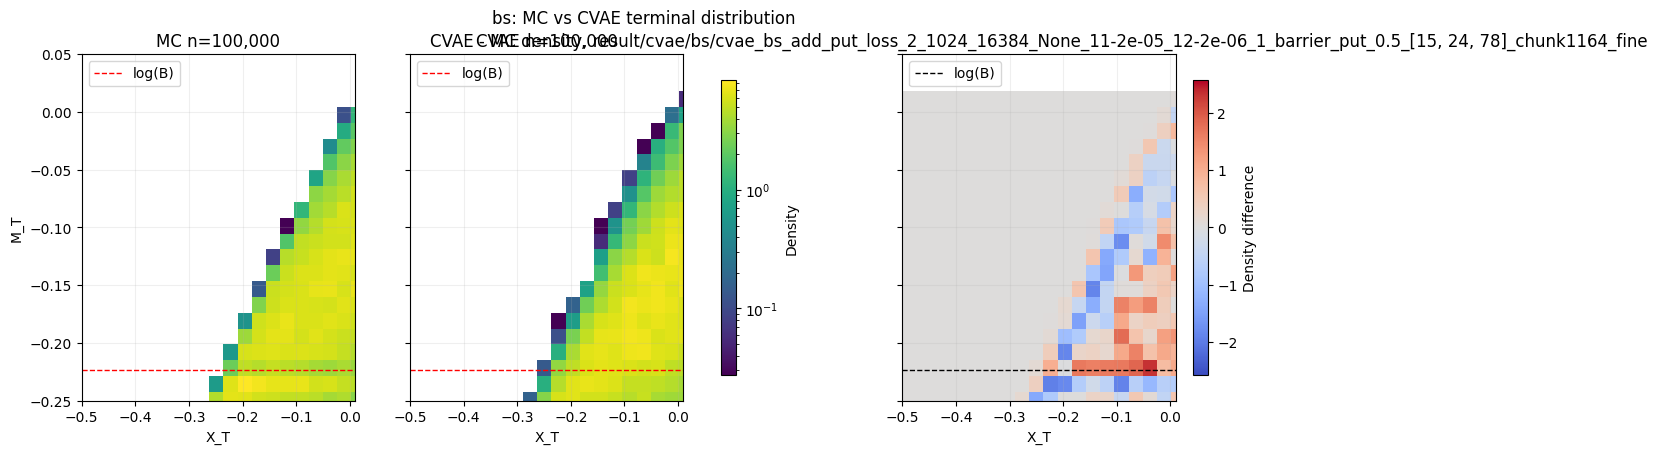

In [183]:
# MC vs CVAE (X_T, M_T) 2D distribution comparison, no pricing
from matplotlib.colors import LogNorm
from e_0_generate import gen_bs_paths, gen_heston_paths

compare_n_samples = 100000
compare_dt = 0.001
plot_bins = 100

with torch.no_grad():
    cvae_samples = cvae.sample(eta_t, compare_n_samples).cpu().numpy()
    if cvae_samples.shape[1] < 2:
        raise ValueError("CVAE sample output must contain both X_T and M_T.")
cvae_xt = cvae_samples[:, 0].astype(np.float64)
cvae_mt = cvae_samples[:, 1].astype(np.float64)

if model_type in ("bs", "bs_clip"):
    mc_xt, mc_mt, mc_mask = gen_bs_paths(
        eta_raw, S0=S0, B=B, n_paths=compare_n_samples, dt=compare_dt
    )
elif model_type in ("hes", "hes_clip"):
    mc_xt, mc_mt, mc_mask = gen_heston_paths(
        eta_raw, S0=S0, B=B, n_paths=compare_n_samples, dt=compare_dt
    )
else:
    raise ValueError(f"Unknown model_type: {model_type}")

mc_xt = np.asarray(mc_xt, dtype=np.float64)
mc_mt = np.asarray(mc_mt, dtype=np.float64)
if not mc_mask:
    print("warning: MC path filter returned False for this sample batch.")

x_all = np.concatenate([mc_xt, cvae_xt])
m_all = np.concatenate([mc_mt, cvae_mt])
x_lo = np.min(x_all)
x_hi = np.max(x_all)
m_lo = np.min(m_all)
m_hi = np.max(m_all)

x_edges = np.linspace(x_lo, x_hi, plot_bins + 1)
m_edges = np.linspace(m_lo, m_hi, plot_bins + 1)
mc_hist, _, _ = np.histogram2d(mc_xt, mc_mt, bins=[x_edges, m_edges], density=True)
cvae_hist, _, _ = np.histogram2d(cvae_xt, cvae_mt, bins=[x_edges, m_edges], density=True)

positive = np.concatenate([mc_hist[mc_hist > 0], cvae_hist[cvae_hist > 0]])
vmin = positive.min() if positive.size else 1e-12
vmax = positive.max() if positive.size else 1.0
extent = [x_edges[0], x_edges[-1], m_edges[0], m_edges[-1]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)

for ax, hist, title in zip(
    axes[:2],
    [mc_hist, cvae_hist],
    [f"MC n={compare_n_samples:,}", f"CVAE n={compare_n_samples:,}"],
):
    im = ax.imshow(
        hist.T,
        origin="lower",
        extent=extent,
        aspect="auto",
        cmap="viridis",
        norm=LogNorm(vmin=vmin, vmax=vmax),
    )
    ax.axhline(np.log(B), color="red", linestyle="--", linewidth=1.0, label="log(B)")
    ax.set_title(title)
    ax.set_xlabel("X_T")
    ax.grid(alpha=0.2)
    ax.legend(loc="upper left")

axes[0].set_ylabel("M_T")
fig.colorbar(im, ax=axes[:2], shrink=0.85, label="Density")

diff = cvae_hist - mc_hist
max_abs_diff = np.nanmax(np.abs(diff)) if np.isfinite(diff).any() else 1.0
im_diff = axes[2].imshow(
    diff.T,
    origin="lower",
    extent=extent,
    aspect="auto",
    cmap="coolwarm",
    vmin=-max_abs_diff,
    vmax=max_abs_diff,
)
axes[2].axhline(np.log(B), color="black", linestyle="--", linewidth=1.0, label="log(B)")
axes[2].set_title(f"CVAE - MC density, {result_base_path}")
axes[2].set_xlabel("X_T")
axes[2].grid(alpha=0.2)
axes[2].set_xlim(-0.5, 0.01)
axes[2].set_ylim(-0.25, 0.05)
axes[2].legend(loc="upper left")
fig.colorbar(im_diff, ax=axes[2], shrink=0.85, label="Density difference")

fig.suptitle(f"{model_type}: MC vs CVAE terminal distribution")
plt.show()

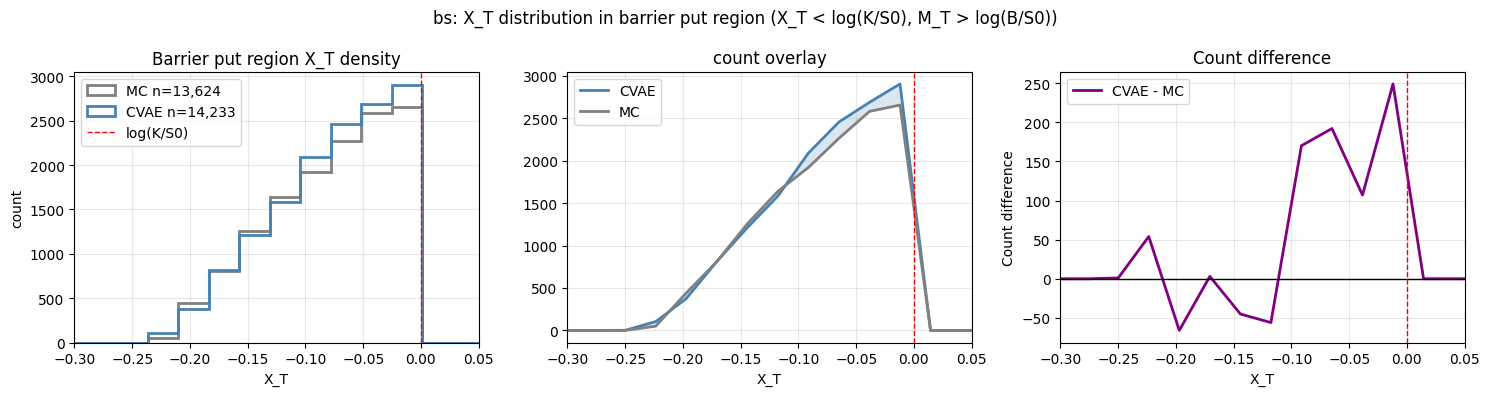

Barrier put threshold: X_T < 0.000000, M_T > -0.223144
MC   count/ratio: 13,624 / 100,000 = 13.6240%
CVAE count/ratio: 14,233 / 100,000 = 14.2330%
MC   X_T mean/std in BP region: -0.077720 / 0.053262
CVAE X_T mean/std in BP region: -0.075942 / 0.052956


In [184]:
# Barrier put region only: compare X_T distribution, no M_T axis
required_vars = ["mc_xt", "mc_mt", "cvae_xt", "cvae_mt"]
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise NameError(f"Run cell 16 first. Missing variables: {missing_vars}")

bp_bins = 100

k_log = np.log(K / S0)
b_log = np.log(B / S0)

# Barrier put payoff region: put ITM and alive above barrier.
mc_bp_mask = (mc_xt < k_log) & (mc_mt > b_log)
cvae_bp_mask = (cvae_xt < k_log) & (cvae_mt > b_log)

mc_bp_xt = np.asarray(mc_xt[mc_bp_mask], dtype=np.float64)
cvae_bp_xt = np.asarray(cvae_xt[cvae_bp_mask], dtype=np.float64)

if len(mc_bp_xt) == 0 or len(cvae_bp_xt) == 0:
    raise ValueError(
        f"No barrier-put samples to compare: MC={len(mc_bp_xt)}, CVAE={len(cvae_bp_xt)}"
    )

x_bp_all = np.concatenate([mc_bp_xt, cvae_bp_xt])
x_lo = np.min(x_all)
x_hi = np.max(x_all)

if not np.isfinite(x_lo) or not np.isfinite(x_hi) or x_lo == x_hi:
    x_lo, x_hi = float(np.min(x_bp_all)), float(np.max(x_bp_all))
    if x_lo == x_hi:
        x_lo -= 1e-6
        x_hi += 1e-6

x_edges = np.linspace(x_lo, x_hi, bp_bins + 1)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

mc_density, _ = np.histogram(mc_bp_xt, bins=x_edges, density=False)
cvae_density, _ = np.histogram(cvae_bp_xt, bins=x_edges, density=False)
density_diff = cvae_density - mc_density

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
axes[0].set_xlim(-0.3, 0.05)
axes[0].hist(
    mc_bp_xt,
    bins=x_edges,
    density=False,
    histtype="step",
    linewidth=2,
    color="grey",
    label=f"MC n={len(mc_bp_xt):,}",
)
axes[0].hist(
    cvae_bp_xt,
    bins=x_edges,
    density=False,
    histtype="step",
    linewidth=2,
    color="steelblue",
    label=f"CVAE n={len(cvae_bp_xt):,}",
)
axes[0].axvline(k_log, color="red", linestyle="--", linewidth=1.0, label="log(K/S0)")
axes[0].set_title("Barrier put region X_T density")
axes[0].set_xlabel("X_T")
axes[0].set_ylabel("count")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(x_centers, cvae_density, color="steelblue", linewidth=2, label="CVAE")
axes[1].plot(x_centers, mc_density, color="grey", linewidth=2, label="MC")
axes[1].fill_between(x_centers, mc_density, cvae_density, color="steelblue", alpha=0.2)
axes[1].axvline(k_log, color="red", linestyle="--", linewidth=1.0)
axes[1].set_title("count overlay")
axes[1].set_xlabel("X_T")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(x_centers, density_diff, color="purple", linewidth=2, label="CVAE - MC")
axes[2].axhline(0.0, color="black", linewidth=1.0)
axes[2].axvline(k_log, color="red", linestyle="--", linewidth=1.0)
axes[2].set_title("Count difference")
axes[2].set_xlabel("X_T")
axes[2].set_ylabel("Count difference")
axes[2].grid(alpha=0.3)
axes[2].legend()

fig.suptitle(
    f"{model_type}: X_T distribution in barrier put region "
    f"(X_T < log(K/S0), M_T > log(B/S0))"
)
plt.tight_layout()
plt.show()


print(f"Barrier put threshold: X_T < {k_log:.6f}, M_T > {b_log:.6f}")
print(f"MC   count/ratio: {len(mc_bp_xt):,} / {len(mc_xt):,} = {len(mc_bp_xt) / len(mc_xt):.4%}")
print(f"CVAE count/ratio: {len(cvae_bp_xt):,} / {len(cvae_xt):,} = {len(cvae_bp_xt) / len(cvae_xt):.4%}")
print(f"MC   X_T mean/std in BP region: {mc_bp_xt.mean():.6f} / {mc_bp_xt.std():.6f}")
print(f"CVAE X_T mean/std in BP region: {cvae_bp_xt.mean():.6f} / {cvae_bp_xt.std():.6f}")


# check eta distribution

In [ ]:
from e_0_generate import *
# eta min_max
if model_type == 'hes':
    prefix = 'heston'
else:
    prefix = model_type

result = compare_eta_minmax_all_vs_used_parallel( # 4m
    eta_path=eta_path,
    chunk_dir=chunk_dir,
    prefix=prefix,
    chunk_idxs=range(100),
    row_batch_size=100*(2**10),
    max_workers=8,
)

done: bs_chunk_007.h5 | unique idx in batches sum=65,536
done: bs_chunk_004.h5 | unique idx in batches sum=65,536
done: bs_chunk_005.h5 | unique idx in batches sum=65,536
done: bs_chunk_003.h5 | unique idx in batches sum=65,536
done: bs_chunk_001.h5 | unique idx in batches sum=65,536
done: bs_chunk_002.h5 | unique idx in batches sum=65,536
done: bs_chunk_000.h5 | unique idx in batches sum=65,536
done: bs_chunk_006.h5 | unique idx in batches sum=65,536
done: bs_chunk_008.h5 | unique idx in batches sum=65,536
done: bs_chunk_010.h5 | unique idx in batches sum=65,536
done: bs_chunk_015.h5 | unique idx in batches sum=65,536
done: bs_chunk_013.h5 | unique idx in batches sum=65,536
done: bs_chunk_009.h5 | unique idx in batches sum=65,536
done: bs_chunk_011.h5 | unique idx in batches sum=65,536
done: bs_chunk_012.h5 | unique idx in batches sum=65,536
done: bs_chunk_014.h5 | unique idx in batches sum=65,536
done: bs_chunk_018.h5 | unique idx in batches sum=65,536
done: bs_chunk_016.h5 | unique 

reading: bs_chunk_000.h5
reading: bs_chunk_001.h5
reading: bs_chunk_002.h5
reading: bs_chunk_003.h5
reading: bs_chunk_004.h5
reading: bs_chunk_005.h5
reading: bs_chunk_006.h5
reading: bs_chunk_007.h5
reading: bs_chunk_008.h5
reading: bs_chunk_009.h5
reading: bs_chunk_010.h5
reading: bs_chunk_011.h5
reading: bs_chunk_012.h5
reading: bs_chunk_013.h5
reading: bs_chunk_014.h5
reading: bs_chunk_015.h5
reading: bs_chunk_016.h5
reading: bs_chunk_017.h5
reading: bs_chunk_018.h5
reading: bs_chunk_019.h5
reading: bs_chunk_020.h5
reading: bs_chunk_021.h5
reading: bs_chunk_022.h5
reading: bs_chunk_023.h5
reading: bs_chunk_024.h5
reading: bs_chunk_025.h5
reading: bs_chunk_026.h5
reading: bs_chunk_027.h5
reading: bs_chunk_028.h5
reading: bs_chunk_029.h5
reading: bs_chunk_030.h5
reading: bs_chunk_031.h5
reading: bs_chunk_032.h5
reading: bs_chunk_033.h5
reading: bs_chunk_034.h5
reading: bs_chunk_035.h5
reading: bs_chunk_036.h5
reading: bs_chunk_037.h5
reading: bs_chunk_038.h5
reading: bs_chunk_039.h5


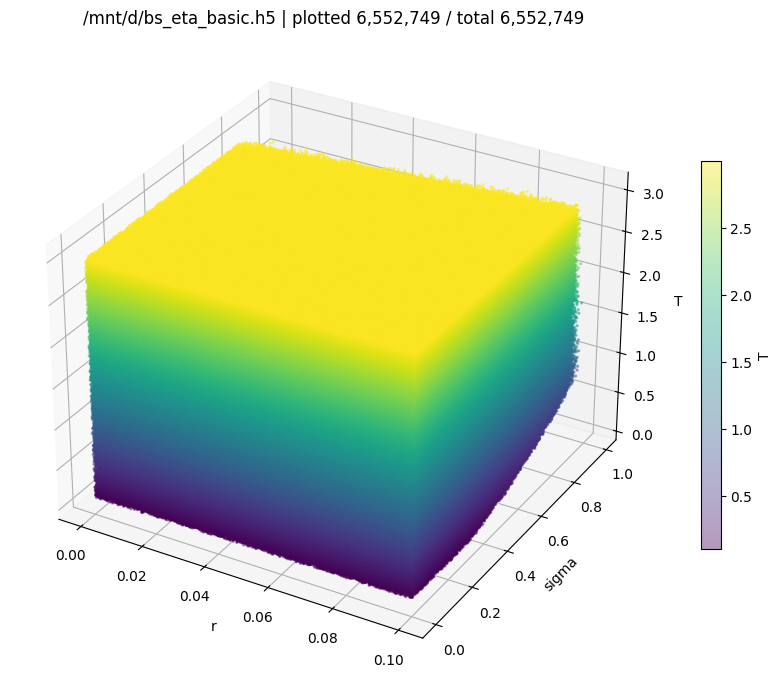

(array([       0,        2,        3, ..., 10776443, 10776444, 10776452],
       shape=(6552749,)),
 array([[0.01915195, 0.2364171 , 1.20417231],
        [0.04377277, 0.27285786, 2.86827853],
        [0.07853586, 0.73582226, 0.98725591],
        ...,
        [0.01301919, 0.36285841, 1.61197575],
        [0.09523179, 0.14520463, 1.33895806],
        [0.09136396, 0.22809733, 0.32350732]], shape=(6552749, 3)))

In [ ]:
# eta distribution
eta_idx = collect_eta_indices_from_chunks(
    chunk_dir=chunk_dir, eta_path=eta_path
)

eta_idx = np.asarray(eta_idx, dtype=np.int64)

with h5py.File("/mnt/d/bs_eta_basic.h5", "r") as h5:
    etas = h5["etas"][np.sort(eta_idx)]

In [ ]:
plot_eta_3d_density_scatter(etas, 
                            max_plot_points=200_000, 
                            bins=40,
                            elev=90,
                            azim=2,
                            )

NameError: name 'plot_eta_3d_density_scatter' is not defined

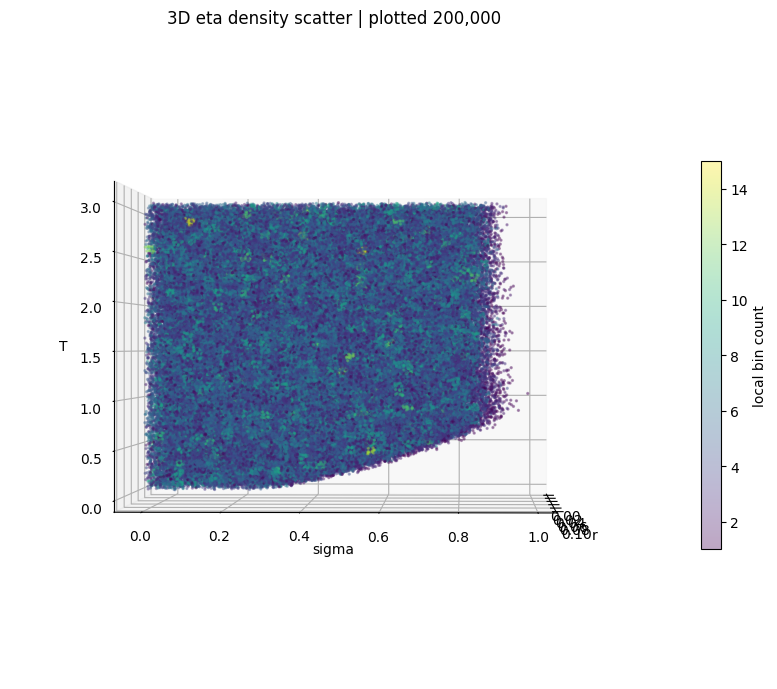

(array([[0.01923302, 0.03761809, 2.26668072],
        [0.0215819 , 0.28683947, 0.48302337],
        [0.08090458, 0.58038402, 1.77076816],
        ...,
        [0.02007971, 0.57556082, 2.45883169],
        [0.05025487, 0.1454769 , 1.7955309 ],
        [0.01083857, 0.41216508, 0.49160411]], shape=(200000, 3)),
 array([5., 6., 4., ..., 3., 6., 5.], shape=(200000,)))

In [74]:
plot_eta_3d_density_scatter(etas, 
                            max_plot_points=200_000, 
                            bins=40,
                            elev=0,
                            azim=2,
                            )

# robust checking

In [251]:
# new robust value
from pathlib import Path
from f_robust import (
    ROBUSTNESS_VARIABLES_MAIN,
    build_sampling_summary,
    plot_sampling_comparison,
    run_robustness,
    save_robustness_results,
)

robust_config = {
    "models": (model_type,),
    "barrier": B,
    "barr_types": ("van", "barr"),
    "option_types": ("call", "put"),
    "run_fdm": True,
    "run_mc": True,
    "n_samples_list": (1_000, 10_000, 100_000),
    "mc_repeats": 50,
    "mc_dt": 0.001,
    "cvae": cvae,
    "checkpoint": ckpt,
    "device": device,
    "cvae_repeats": 50,
}

robust_results = run_robustness( # bs : 7m, hes : 
    BS_eta,
    Hes_eta,
    ROBUSTNESS_VARIABLES_MAIN,
    **robust_config,
)

robust_stem = f"{Path(save_path).stem}_robustness"
pickle_path, csv_path = save_robustness_results(
    robust_results,
    output_dir="result/robust",
    stem=robust_stem,
)
print("raw results  :", pickle_path)
print("summary      :", csv_path)

[001] bs | r=0.0025 | van call
[002] bs | r=0.0025 | van put
[003] bs | r=0.0025 | barr call
[004] bs | r=0.0025 | barr put
[005] bs | r=0.0975 | van call
[006] bs | r=0.0975 | van put
[007] bs | r=0.0975 | barr call
[008] bs | r=0.0975 | barr put
[009] bs | sigma=0.05 | van call
[010] bs | sigma=0.05 | van put
[011] bs | sigma=0.05 | barr call
[012] bs | sigma=0.05 | barr put
[013] bs | sigma=0.75 | van call
[014] bs | sigma=0.75 | van put
[015] bs | sigma=0.75 | barr call
[016] bs | sigma=0.75 | barr put
[017] bs | T=0.15 | van call
[018] bs | T=0.15 | van put
[019] bs | T=0.15 | barr call
[020] bs | T=0.15 | barr put
[021] bs | T=2.85 | van call
[022] bs | T=2.85 | van put
[023] bs | T=2.85 | barr call
[024] bs | T=2.85 | barr put
raw results  : result/robust/cvae_bs_2_1024_16384_None_11-2e-05_12-2e-06_1_[15, 24, 78]_chunk1164_robustness.pkl
summary      : result/robust/cvae_bs_2_1024_16384_None_11-2e-05_12-2e-06_1_[15, 24, 78]_chunk1164_robustness_summary.csv


In [150]:
# change model
# robust 값만 같다면 cvae값만 업데이트
from pathlib import Path
from f_robust import (
    ROBUSTNESS_VARIABLES_MAIN,
    build_sampling_summary,
    plot_sampling_comparison,
    run_robustness,
    save_robustness_results,
)

if model_type == 'bs' or model_type == 'bs_clip':
    old_robust_path = Path("result/robust/cvae_bs_2_128_4096_None_0.0001_1_[15, 24, 78]_chunk1261_robustness.pkl")
else:
    old_robust_path = Path("result/robust/cvae_hes_2_128_4096_None_0.0001_1_[15, 24, 78]_chunk776_robustness.pkl")
old_results = pd.read_pickle(old_robust_path).copy()
old_results["model"] = model_type

new_cvae_results = run_robustness(
    BS_eta,
    Hes_eta,
    ROBUSTNESS_VARIABLES_MAIN,
    models=(model_type,),
    barrier=B,
    barr_types=("van", "barr"),
    option_types=("call", "put"),
    run_fdm=False,
    run_mc=False,
    n_samples_list=(1_000, 10_000, 100_000),
    mc_repeats=50,
    mc_dt=0.001,
    cvae=cvae,
    checkpoint=ckpt,
    device=device,
    cvae_repeats=50,
)

key_cols = ["model", "variable", "value", "barr_type", "option_type"]

cvae_cols = [
    "cvae",
    "cvae_std",
    "cvae_seconds",
    "cvae_results",
    "cvae_seconds_by_n",
    "cvae_abs_error",
    "cvae_rel_error_pct",
]

new_results = old_results.drop(
    columns=[col for col in cvae_cols if col in old_results.columns],
    errors="ignore",
).merge(
    new_cvae_results[key_cols + cvae_cols],
    on=key_cols,
    how="left",
)

robust_stem = f"{Path(save_path).stem}_robustness"

pickle_path, csv_path = save_robustness_results(
    new_results,
    output_dir="result/robust",
    stem=robust_stem,
)

print("raw results:", pickle_path)
print("summary    :", csv_path)

[001] bs | r=0.0025 | van call
[002] bs | r=0.0025 | van put
[003] bs | r=0.0025 | barr call
[004] bs | r=0.0025 | barr put
[005] bs | r=0.0975 | van call
[006] bs | r=0.0975 | van put
[007] bs | r=0.0975 | barr call
[008] bs | r=0.0975 | barr put
[009] bs | sigma=0.05 | van call
[010] bs | sigma=0.05 | van put
[011] bs | sigma=0.05 | barr call
[012] bs | sigma=0.05 | barr put
[013] bs | sigma=0.8 | van call
[014] bs | sigma=0.8 | van put
[015] bs | sigma=0.8 | barr call
[016] bs | sigma=0.8 | barr put
[017] bs | T=0.15 | van call
[018] bs | T=0.15 | van put
[019] bs | T=0.15 | barr call
[020] bs | T=0.15 | barr put
[021] bs | T=2.85 | van call
[022] bs | T=2.85 | van put
[023] bs | T=2.85 | barr call
[024] bs | T=2.85 | barr put
raw results: result/robust/cvae_bs_add_put_loss_2_1024_16384_None_14-2e-05_15-2e-06_1_barrier_put_1.0_[15, 24, 78]_chunk1649_robustness.pkl
summary    : result/robust/cvae_bs_add_put_loss_2_1024_16384_None_14-2e-05_15-2e-06_1_barrier_put_1.0_[15, 24, 78]_chunk


bs | r=0.0025


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
0,van,call,1000,0.110592,0.110482,0.006221,0.099747,0.111282,0.005875,0.623600
1,van,call,10000,0.110592,0.109961,0.001969,0.570767,0.110415,0.001748,0.160374
2,van,call,100000,0.110592,0.110598,0.000610,0.004978,0.110807,0.000661,0.194551
3,van,put,1000,0.106849,0.106748,0.003966,0.095045,0.105025,0.003627,1.706954
4,van,put,10000,0.106849,0.106906,0.001330,0.053024,0.106060,0.001665,0.738366
5,van,put,100000,0.106849,0.106944,0.000426,0.089080,0.105991,0.000456,0.802873
6,barr,call,1000,0.104650,0.104641,0.006436,0.008771,0.105533,0.006067,0.843771
7,barr,call,10000,0.104650,0.104030,0.002011,0.592600,0.104629,0.001708,0.020216
8,barr,call,100000,0.104650,0.104644,0.000559,0.006056,0.104994,0.000639,0.329004
9,barr,put,1000,0.010502,0.010496,0.001085,0.056026,0.010677,0.000777,1.669211


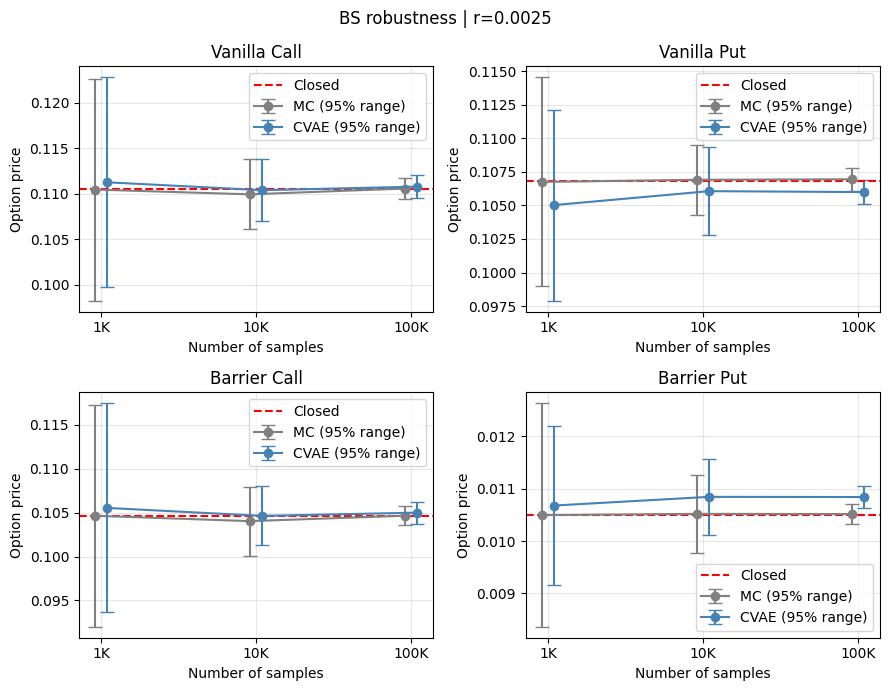


bs | r=0.0975


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
12,van,call,1000,0.183554,0.182742,0.007280,0.442462,0.182196,0.007949,0.739948
13,van,call,10000,0.183554,0.183449,0.002789,0.057266,0.184556,0.002150,0.545799
14,van,call,100000,0.183554,0.183322,0.000837,0.126623,0.184113,0.000822,0.304257
15,van,put,1000,0.047496,0.048155,0.003187,1.387753,0.047299,0.002983,0.415129
16,van,put,10000,0.047496,0.047553,0.000894,0.120251,0.046670,0.000886,1.738727
17,van,put,100000,0.047496,0.047537,0.000289,0.086459,0.046841,0.000272,1.379651
18,barr,call,1000,0.176219,0.175391,0.007091,0.470242,0.175305,0.007945,0.518742
19,barr,call,10000,0.176219,0.176072,0.002735,0.083445,0.177546,0.002156,0.752515
20,barr,call,100000,0.176219,0.175970,0.000862,0.141268,0.177070,0.000806,0.482554
21,barr,put,1000,0.006855,0.006791,0.000946,0.928964,0.007247,0.000743,5.723109


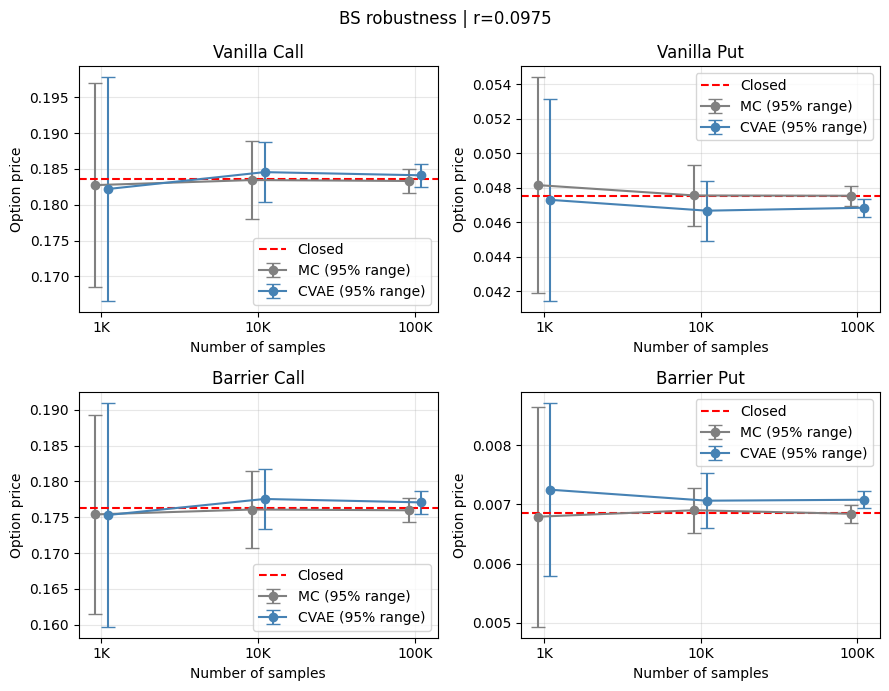


bs | sigma=0.05


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
24,van,call,1000,0.052062,0.052128,0.001701,0.126553,0.052069,0.001680,0.013847
25,van,call,10000,0.052062,0.052021,0.000556,0.078817,0.052177,0.000569,0.222453
26,van,call,100000,0.052062,0.052060,0.000166,0.003739,0.052225,0.000147,0.314616
27,van,put,1000,0.008059,0.008197,0.000622,1.715386,0.008110,0.000660,0.636920
28,van,put,10000,0.008059,0.008102,0.000219,0.528900,0.008148,0.000176,1.099678
29,van,put,100000,0.008059,0.008055,0.000052,0.050163,0.008126,0.000061,0.829834
30,barr,call,1000,0.052062,0.052128,0.001701,0.126553,0.052069,0.001680,0.013847
31,barr,call,10000,0.052062,0.052021,0.000556,0.078817,0.052177,0.000569,0.222453
32,barr,call,100000,0.052062,0.052060,0.000166,0.003739,0.052225,0.000147,0.314616
33,barr,put,1000,0.008056,0.008197,0.000622,1.754534,0.008110,0.000660,0.675654


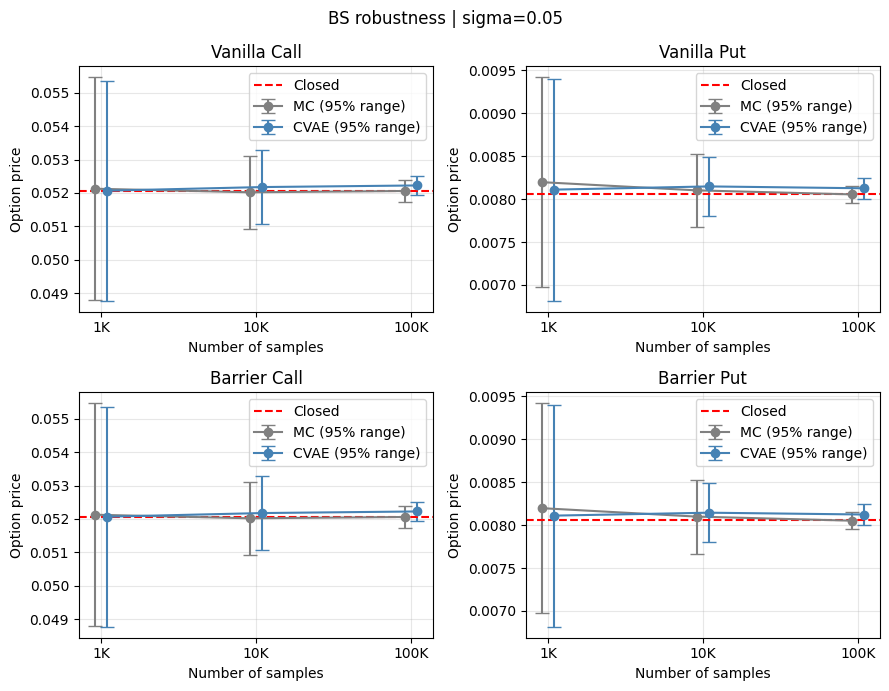


bs | sigma=0.8


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
36,van,call,1000,0.389885,0.389683,0.036722,0.051678,0.403962,0.037073,3.610659
37,van,call,10000,0.389885,0.388580,0.009892,0.334673,0.405711,0.012014,4.059144
38,van,call,100000,0.389885,0.389899,0.003759,0.003706,0.403244,0.003978,3.426360
39,van,put,1000,0.345882,0.345260,0.010896,0.179869,0.341569,0.011025,1.246920
40,van,put,10000,0.345882,0.346917,0.002435,0.299244,0.339889,0.003635,1.732855
41,van,put,100000,0.345882,0.345764,0.000769,0.034250,0.340398,0.001044,1.585656
42,barr,call,1000,0.188650,0.188925,0.029726,0.145638,0.197741,0.032145,4.819298
43,barr,call,10000,0.188650,0.188210,0.007552,0.233149,0.200777,0.010623,6.428632
44,barr,call,100000,0.188650,0.188951,0.003297,0.159876,0.198802,0.003174,5.381376
45,barr,put,1000,0.000292,0.000312,0.000162,6.801918,0.000349,0.000180,19.400328


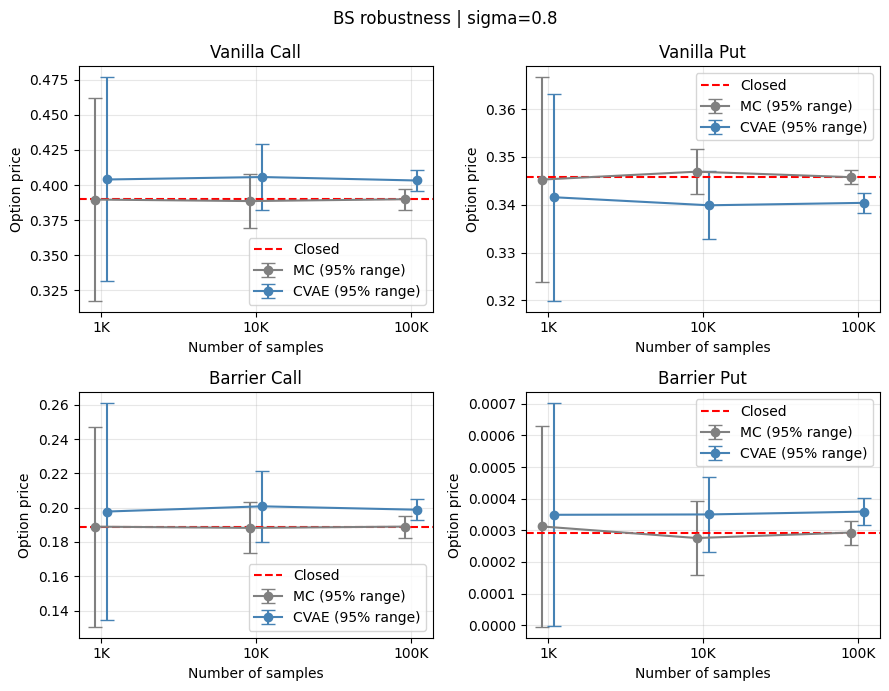


bs | T=0.15


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
48,van,call,1000,0.036753,0.037021,0.001800,0.730612,0.036990,0.002026,0.645068
49,van,call,10000,0.036753,0.036701,0.000518,0.139159,0.036890,0.000585,0.373265
50,van,call,100000,0.036753,0.036762,0.000118,0.026002,0.037003,0.000191,0.681978
51,van,put,1000,0.032263,0.032410,0.001300,0.455806,0.032282,0.001358,0.060712
52,van,put,10000,0.032263,0.032335,0.000436,0.225460,0.032459,0.000538,0.609233
53,van,put,100000,0.032263,0.032267,0.000142,0.014713,0.032411,0.000140,0.459055
54,barr,call,1000,0.036753,0.037021,0.001800,0.730617,0.036990,0.002026,0.645074
55,barr,call,10000,0.036753,0.036701,0.000518,0.139153,0.036890,0.000585,0.373270
56,barr,call,100000,0.036753,0.036762,0.000118,0.025997,0.037003,0.000191,0.681980
57,barr,put,1000,0.030327,0.030435,0.001270,0.358524,0.030683,0.001445,1.175734


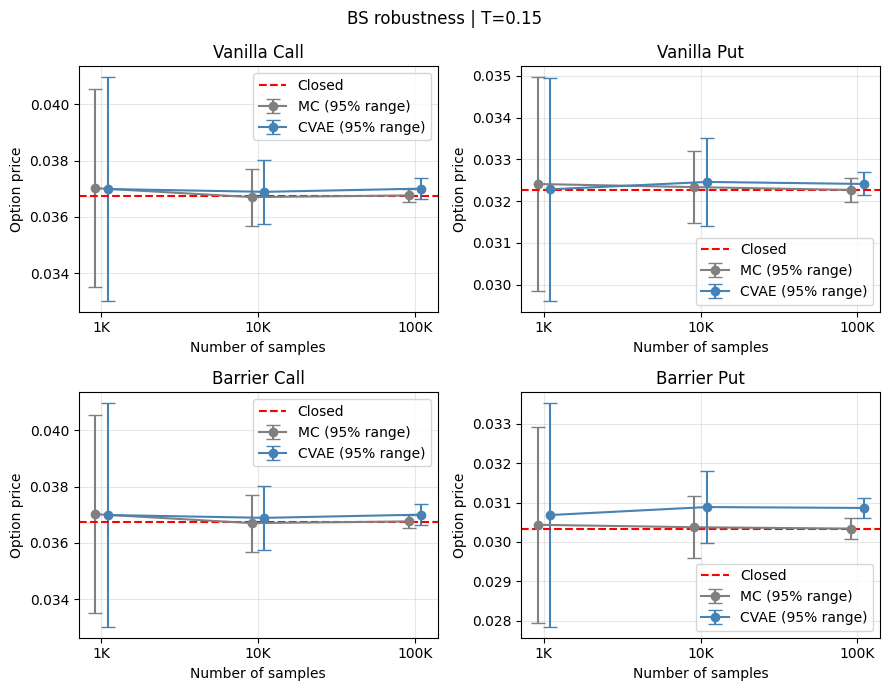


bs | T=2.85


,barr_type,option_type,n_samples,reference,mc_mean,mc_std,mc_rel_error_pct,cvae_mean,cvae_std,cvae_rel_error_pct
60,van,call,1000,0.188168,0.190094,0.009266,1.023408,0.188622,0.009723,0.241158
61,van,call,10000,0.188168,0.188417,0.002867,0.132201,0.188290,0.003220,0.064793
62,van,call,100000,0.188168,0.188247,0.000923,0.042080,0.188742,0.000925,0.305136
63,van,put,1000,0.106221,0.106690,0.004040,0.441411,0.105791,0.004926,0.404902
64,van,put,10000,0.106221,0.106331,0.001399,0.103348,0.105129,0.001609,1.028837
65,van,put,100000,0.106221,0.106161,0.000439,0.057009,0.105154,0.000502,1.005133
66,barr,call,1000,0.163381,0.165080,0.009787,1.040256,0.164763,0.009143,0.845860
67,barr,call,10000,0.163381,0.163458,0.002737,0.047083,0.164102,0.003196,0.441101
68,barr,call,100000,0.163381,0.163417,0.000892,0.022209,0.164484,0.000885,0.675251
69,barr,put,1000,0.004219,0.004140,0.000591,1.860588,0.004463,0.000697,5.785012


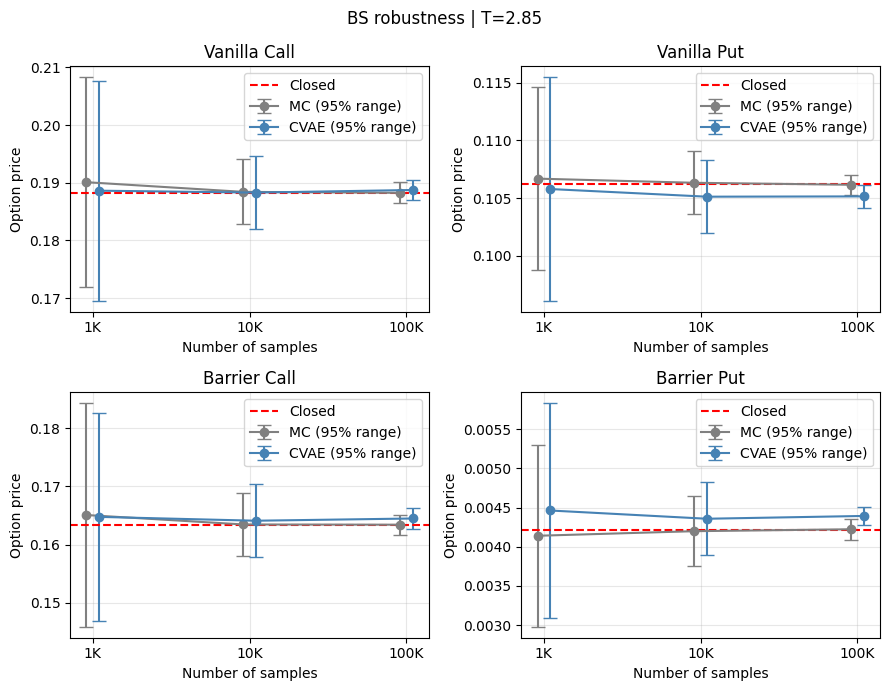

In [151]:
import pandas as pd
from f_robust import (
    ROBUSTNESS_VARIABLES_MAIN,
    build_sampling_summary,
    plot_sampling_comparison,
    run_robustness,
    save_robustness_results,
)

robust_stem = f"{Path(save_path).stem}_robustness"
pkl_path = Path("result/robust") / f"{robust_stem}.pkl"
robust_results = pd.read_pickle(pkl_path)
# 예전 파일이 bs/hes 라벨로 저장된 경우, 현재 CVAE 모델명(bs_clip/hes_clip)에 맞춰 표시한다.
if "model" in robust_results.columns and model_type not in set(robust_results["model"].astype(str)):
    if model_type in {"bs_clip", "hes_clip"}:
        robust_results = robust_results.copy()
        robust_results["model"] = model_type

sampling_summary = build_sampling_summary(robust_results)

for variable, values in ROBUSTNESS_VARIABLES_MAIN[model_type].items():
    for value in values:
        print(f"\n{model_type} | {variable}={value:g}")
        case_summary = sampling_summary[
            sampling_summary["model"].eq(model_type)
            & sampling_summary["variable"].eq(variable)
            & np.isclose(sampling_summary["value"], value)
        ]
        display(case_summary[[
            "barr_type",
            "option_type",
            "n_samples",
            "reference",
            "mc_mean",
            "mc_std",
            "mc_rel_error_pct",
            "cvae_mean",
            "cvae_std",
            "cvae_rel_error_pct",
        ]])

        plot_sampling_comparison(
            robust_results,
            model_type,
            variable,
            value,
        )

failed_cases = robust_results[robust_results["error"].notna()]
if not failed_cases.empty:
    print("\n계산 실패 항목")
    display(failed_cases[[
        "model", "variable", "value", "barr_type", "option_type", "error"
    ]])